### import libraries

In [15]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocessing as mp
import shutil

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

### Transmission

In [16]:
tpad = 1000
xpad = 64
ypad = 64

hwKalpha1N = 8047.91

### reading and plotting

In [17]:
figs_path = os.path.join(base_directory, 'figs')
if not os.path.exists(figs_path):
    os.makedirs(figs_path)

In [25]:
data_path = "../data/mono_sweep"

In [ ]:
sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys=('E_seed_uJ', 'monochromator_target_energy_eV'),
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 'sigma1_Ka1_other', 'seed_duration_FWHM_t', 'hwKalpha1N'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, hwKalpha1N = aux_data

In [ ]:
plt.figure()

str_pars_grid = " Nx = " + str(xgrid) + ", Ny = " + str(ygrid) + ", Nz = " + str(zgrid) + ", Nt = " + str(tgrid)
str_pars_calc = r'$\sigma_{2p}$ = ' + f'{1e7*sigma1_Ka1_2p3:.1f}' + ' kbarn' + \
r', $\sigma_{other}$ = ' + f'{1e7*sigma1_Ka1_other:.1f}' +' kbarn' + \
r', $t_{seed}^{FWHM}$ = ' + f'{seed_duration_FWHM_t:.1f}' +' fs'

plt.title('average over ' + str(num_files) + ' SASE realizations per point' + '\n'
+ str_pars_grid + '\n' + str_pars_calc
 )

E_seed_values = list(sorted_accumulated_arrays.keys())
norm = plt.matplotlib.colors.LogNorm(vmin=min(E_seed_values), vmax=max(E_seed_values))
cmap = plt.matplotlib.colormaps['viridis']

transmittance_dict = {}

for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():
    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)

    for i, energy_value in enumerate(energy_values):
        arrays = energy_arrays[energy_value]
        I_int_thy_w_last = arrays['I_int_thy_w_last']
        I_int_thy_w_0 = arrays['I_int_thy_w_0']

        # Transmittance of a monochromated shot: total transmitted over total
        # incident spectral intensity, integrated over the narrow passband
        # selected by the monochromator at this target energy.
        T_values[i] = np.sum(I_int_thy_w_last) / np.sum(I_int_thy_w_0)

    transmittance_dict[E_seed_value] = (energy_values, T_values)

    plt.scatter(energy_values, T_values, color=cmap(norm(E_seed_value)), label='T at ' + str(E_seed_value) + ' uJ')
    plt.plot(energy_values, T_values, color=cmap(norm(E_seed_value)))

plt.axvline(hwKalpha1N, color='gray', ls='--', lw=1, label=r'$E_{K\alpha 1}$' + f' = {hwKalpha1N:.2f} eV')
plt.ylabel(r'$T$')
plt.xlabel(r'$E$ (eV)')
plt.xlim(hwKalpha1N - 15, hwKalpha1N + 15)
plt.legend()
plt.grid(True)
plt.savefig(figs_path + '/mono_' + str_pars_calc + '.pdf')
plt.show()

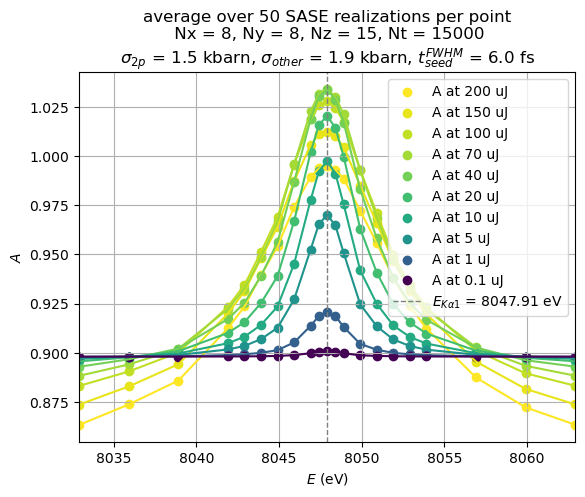

In [22]:
plt.figure()

str_pars_grid = " Nx = " + str(xgrid) + ", Ny = " + str(ygrid) + ", Nz = " + str(zgrid) + ", Nt = " + str(tgrid)
str_pars_calc = r'$\sigma_{2p}$ = ' + f'{1e7*sigma1_Ka1_2p3:.1f}' + ' kbarn' + \
r', $\sigma_{other}$ = ' + f'{1e7*sigma1_Ka1_other:.1f}' +' kbarn' + \
r', $t_{seed}^{FWHM}$ = ' + f'{seed_duration_FWHM_t:.1f}' +' fs'

plt.title('average over ' + str(num_files) + ' SASE realizations per point' + '\n'
+ str_pars_grid + '\n' + str_pars_calc
 )

E_seed_values = list(sorted_accumulated_arrays.keys())
norm = plt.matplotlib.colors.LogNorm(vmin=min(E_seed_values), vmax=max(E_seed_values))
cmap = plt.matplotlib.colormaps['viridis']

for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():
    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)

    for i, energy_value in enumerate(energy_values):
        arrays = energy_arrays[energy_value]
        I_int_thy_w_last = arrays['I_int_thy_w_last']
        I_int_thy_w_0 = arrays['I_int_thy_w_0']

        # Transmittance of a monochromated shot: total transmitted over total
        # incident spectral intensity, integrated over the narrow passband
        # selected by the monochromator at this target energy.
        T_values[i] = np.sum(I_int_thy_w_last) / np.sum(I_int_thy_w_0)
        
    absorbance_values = -np.log(T_values)#tools.transmittance_to_absorbance(T_values)

    plt.scatter(energy_values, absorbance_values, color=cmap(norm(E_seed_value)), label='A at ' + str(E_seed_value) + ' uJ')
    plt.plot(energy_values, absorbance_values, color=cmap(norm(E_seed_value)))

plt.axvline(hwKalpha1N, color='gray', ls='--', lw=1, label=r'$E_{K\alpha 1}$' + f' = {hwKalpha1N:.2f} eV')
plt.ylabel(r'$A$')
plt.xlabel(r'$E$ (eV)')
plt.xlim(hwKalpha1N - 15, hwKalpha1N + 15)
plt.legend()
plt.grid(True)
plt.savefig(figs_path + '/mono_' + str_pars_calc + '.pdf')
plt.show()

In [30]:
sorted_accumulated_arrays[200].keys()

odict_keys([8032.91, 8035.91, 8038.91, 8041.91, 8042.91, 8043.91, 8044.91, 8045.91, 8046.91, 8047.41, 8047.91, 8048.41, 8048.91, 8049.91, 8050.91, 8051.91, 8052.91, 8053.91, 8056.91, 8059.91, 8062.91])

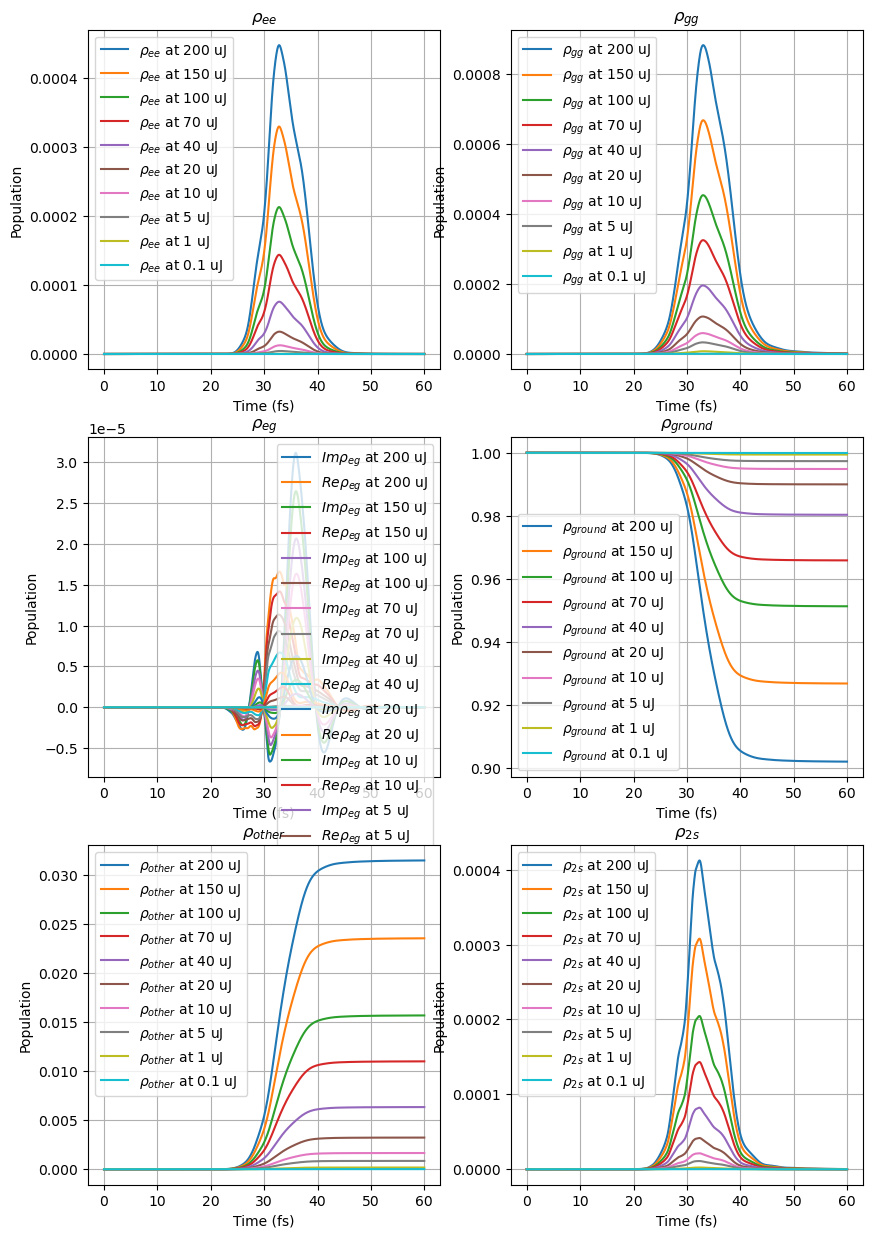

In [31]:
fig, axs = plt.subplots(3, 2, figsize=(10, 15))

for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():

    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)

    energy_value = 8047.91

    arrays = energy_arrays[energy_value]
    rho_ee_t_last = arrays['rho_ee_t_last']
    rho_gg_t_last = arrays['rho_gg_t_last']
    rho_eg_t_last = arrays['rho_eg_t_last']
    rho_ground_t_last = arrays['rho_ground_t_last']
    rho_other_t_last = arrays['rho_other_t_last']
    rho_2s_t_last = arrays['rho_2s_t_last']
    t_axis = arrays['t_axis']

    # Plot 2x2 grid of subplots, for example, plotting rho_ee, rho_gg, rho_eg, and rho_ground
    axs[0, 0].plot(t_axis, rho_ee_t_last, label=rf'$\rho_{{ee}}$ at {E_seed_value} uJ')
    axs[0, 1].plot(t_axis, rho_gg_t_last, label=rf'$\rho_{{gg}}$ at {E_seed_value} uJ')
    axs[1, 0].plot(t_axis, np.imag(rho_eg_t_last), label=rf'$Im\rho_{{eg}}$ at {E_seed_value} uJ')
    axs[1, 0].plot(t_axis, np.real(rho_eg_t_last), label=rf'$Re\rho_{{eg}}$ at {E_seed_value} uJ')
    axs[1, 1].plot(t_axis, rho_ground_t_last, label=rf'$\rho_{{ground}}$ at {E_seed_value} uJ')
    axs[2, 0].plot(t_axis, rho_other_t_last, label=rf'$\rho_{{other}}$ at {E_seed_value} uJ')
    axs[2, 1].plot(t_axis, rho_2s_t_last, label=rf'$\rho_{{2s}}$ at {E_seed_value} uJ')

# Set titles and labels for each subplot
axs[0, 0].set_title(r'$\rho_{ee}$')
axs[0, 1].set_title(r'$\rho_{gg}$')
axs[1, 0].set_title(r'$\rho_{eg}$')
axs[1, 1].set_title(r'$\rho_{ground}$')
axs[2, 0].set_title(r'$\rho_{other}$')
axs[2, 1].set_title(r'$\rho_{2s}$')

# Set x and y labels for each subplot
for ax in axs.flat:
    ax.set_xlabel('Time (fs)')
    ax.set_ylabel('Population')
    ax.legend()
    ax.grid(True)

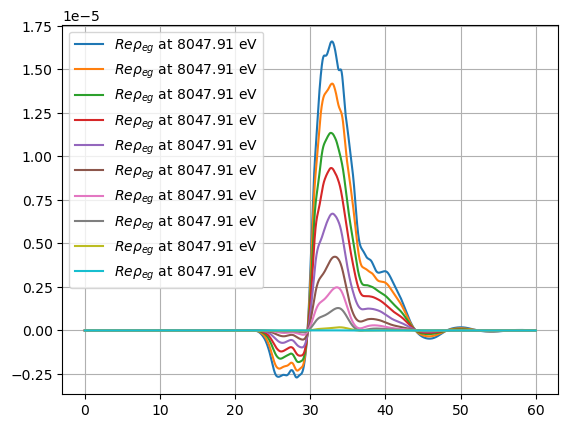

In [32]:
for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():

    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)

    energy_value = 8047.91
    
    arrays = energy_arrays[energy_value]

    rho_ee_t_last = arrays['rho_ee_t_last']
    rho_gg_t_last = arrays['rho_gg_t_last']
    rho_eg_t_last = arrays['rho_eg_t_last']
    rho_ground_t_last = arrays['rho_ground_t_last']
    rho_other_t_last = arrays['rho_other_t_last']
    rho_2s_t_last = arrays['rho_2s_t_last']
    t_axis = arrays['t_axis']

    plt.plot(t_axis[:], np.real(rho_eg_t_last[:]), label=rf'$Re\rho_{{eg}}$ at {energy_value} eV')

plt.legend()
plt.grid(True)

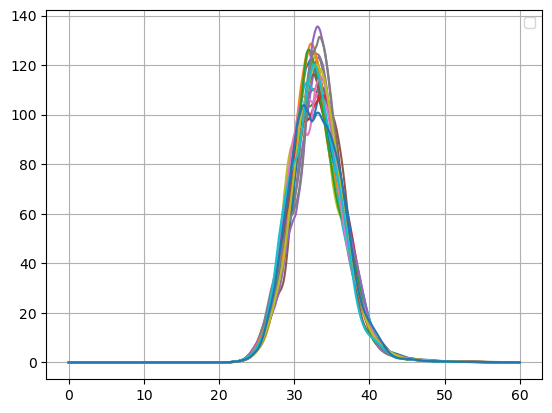

In [25]:


E_seed_value = 40
energy_arrays = sorted_accumulated_arrays[E_seed_value]

for i, energy_value in enumerate(energy_values):
    arrays = energy_arrays[energy_value]
    I_t_0 = arrays["I_t_0"]
    t_axis = arrays['t_axis']

    plt.plot(t_axis[:], I_t_0)

plt.legend()
plt.grid(True)

In [26]:
min_T = []
area_T = []
FWHM_T = []

max_A = []
area_A

for E_seed_value, (energy_values, T_values) in transmittance_dict.items():
    absorbance = -np.log(T_values)
    
    min_T.append(np.min(T_values))

    n_edge = 1
    T_base = 0.5 * (
        np.mean(T_values[:n_edge]) +
        np.mean(T_values[-n_edge:])
    )

    dip = T_base - T_values

    area_T.append(np.trapz(dip, energy_values))
    FWHM_T.append(tools.find_fwhm(energy_values, dip))

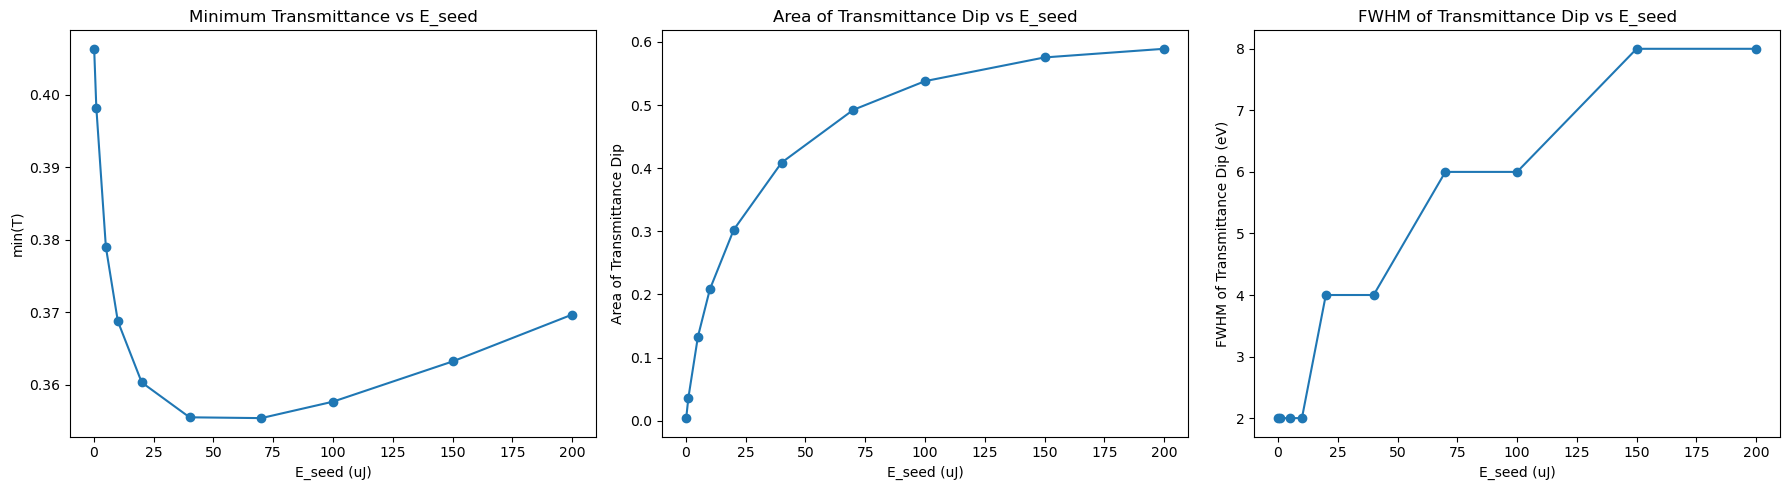

In [27]:
# Plot min_T, area_T, and FWHM_T as functions of E_seed_values in 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(E_seed_values, min_T, marker='o')
axs[0].set_xlabel('E_seed (uJ)')
axs[0].set_ylabel('min(T)')
axs[0].set_title('Minimum Transmittance vs E_seed')

axs[1].plot(E_seed_values, area_T, marker='o')
axs[1].set_xlabel('E_seed (uJ)')
axs[1].set_ylabel('Area of Transmittance Dip')
axs[1].set_title('Area of Transmittance Dip vs E_seed')

axs[2].plot(E_seed_values, FWHM_T, marker='o')
axs[2].set_xlabel('E_seed (uJ)')
axs[2].set_ylabel('FWHM of Transmittance Dip (eV)')
axs[2].set_title('FWHM of Transmittance Dip vs E_seed')

plt.tight_layout()
plt.savefig(figs_path + '/transmittance_metrics_vs_E_seed.pdf')
plt.show()

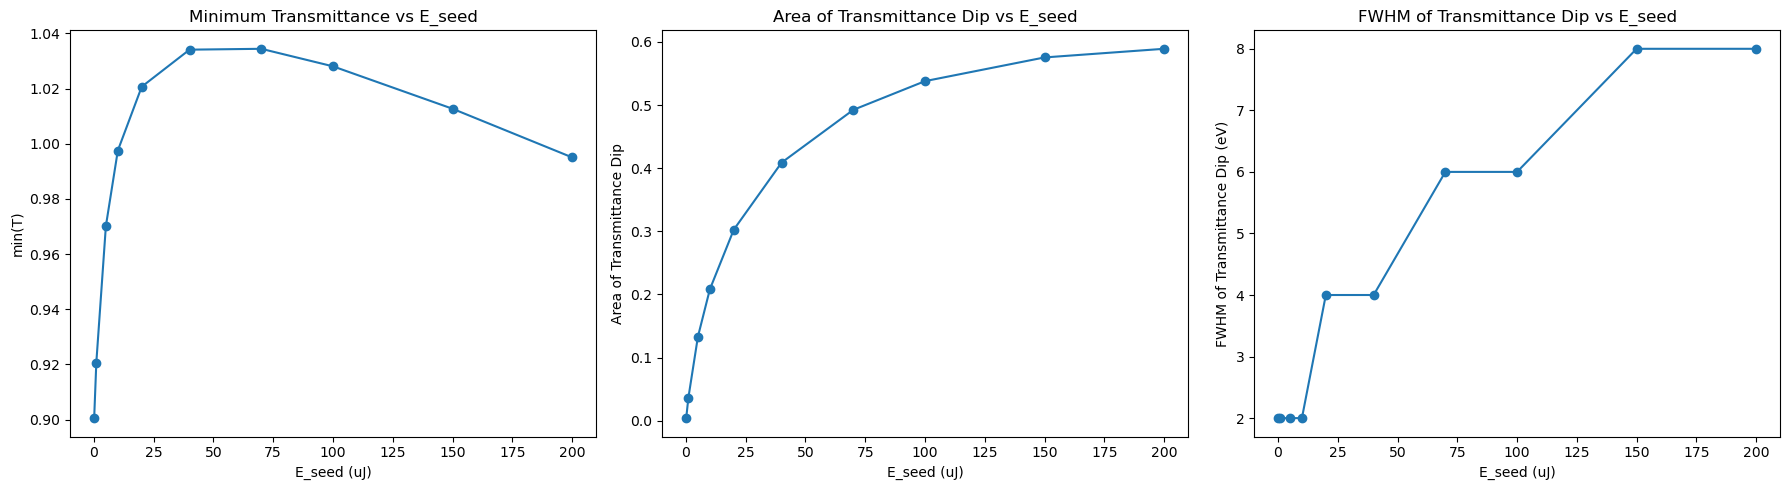

In [28]:
# Plot min_T, area_T, and FWHM_T as functions of E_seed_values in 3 subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(E_seed_values, -np.log(min_T), marker='o')
axs[0].set_xlabel('E_seed (uJ)')
axs[0].set_ylabel('min(T)')
axs[0].set_title('Minimum Transmittance vs E_seed')

axs[1].plot(E_seed_values, area_T, marker='o')
axs[1].set_xlabel('E_seed (uJ)')
axs[1].set_ylabel('Area of Transmittance Dip')
axs[1].set_title('Area of Transmittance Dip vs E_seed')

plt.tight_layout()
plt.savefig(figs_path + '/transmittance_metrics_vs_E_seed.pdf')
plt.show()